In [1]:
import json

def read_partial_jsonl(file_path, max_lines=10, print_content=False):
    """
    读取JSONL文件的前N行
    :param file_path: 文件路径
    :param max_lines: 要读取的最大行数
    :param print_content: 是否打印每条记录的内容
    :return: 包含解析后数据的列表
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        ret = 0
        for i, line in enumerate(f):
            if ret >= max_lines:
                break  # 当读取到最大行数时，停止读取
            try:
                parsed_line = json.loads(line.strip())
                ret += 1
                if print_content:
                    print(f"记录 {ret}: {parsed_line}")  # 打印每条记录的内容
            except json.JSONDecodeError:
                print(f"第 {i+1} 行JSON解析错误，已跳过")
    return ret

# 使用示例（打印前10条记录）
partial_data = read_partial_jsonl(
    './grounding_data/coco/annotations/processed_instances_train2017_vg_merged6.jsonl',
    max_lines=100,
    print_content=True  # 开启打印内容
)
print(f"\n已读取 {partial_data} 条记录")


记录 1: {'filename': '000000272026.jpg', 'height': 480, 'width': 640, 'conversations': [{'from': 'human', 'value': '<image>\nProvide a scene graph caption of the given image.'}, {'from': 'gpt', 'value': 'In the image, three women are sitting at a dining table. They appear to be enjoying themselves, with one leaning on the table and all of them in front of it. The table has several cups and bottles on it, suggesting that they are enjoying drinks. One of the women is beside a wall, and two of the women are beside each other. There is also a chair visible in the image, indicating that they are seated. The setting appears to be a restaurant or a similar dining establishment.'}], 'tags': ['table', 'wall', 'caption', 'restaurant', 'dining establishment'], 'grounding': {'caption': 'keyboard. toaster. hair drier. tennis racket. bicycle. person. tv. cow. parking meter. couch. horse. cell phone. vase. sports ball. umbrella. airplane. apple. donut. suitcase. microwave. laptop. refrigerator. basebal

In [5]:
!pwd

/autodl-fs/data/demo


In [6]:
pip install opencv-python

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 17.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


####  读取一个json绘制图片，然后输出到图片集合当中

原始图像已保存至: ./grounding_data/original_000000272026.jpg
bottle
跳过排除的物体: bottle
dining table
person
跳过排除的物体: person
cup
跳过排除的物体: cup
wine glass
跳过排除的物体: wine glass
chair
跳过排除的物体: chair
wall
跳过排除的物体: wall
标注图已保存至: ./grounding_data/annotated_000000272026.jpg


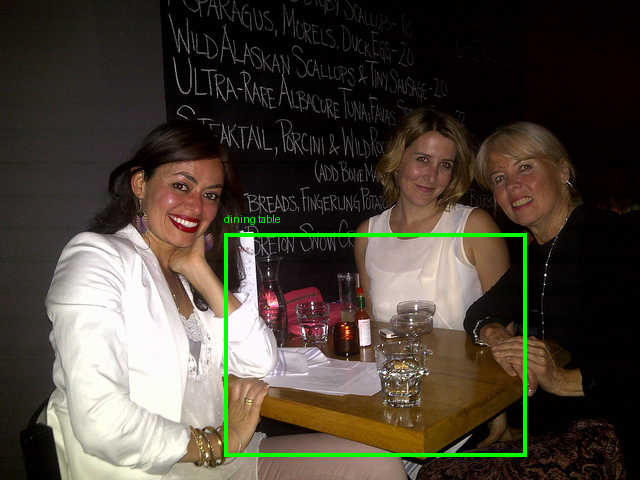

In [7]:
import json
import cv2
import os
from PIL import Image, ImageDraw, ImageFont

# 使用正确的JSON数据
data ={'filename': '000000272026.jpg', 'height': 480, 'width': 640, 'conversations': [{'from': 'human', 'value': '<image>\nProvide a scene graph caption of the given image.'}, {'from': 'gpt', 'value': 'In the image, three women are sitting at a dining table. They appear to be enjoying themselves, with one leaning on the table and all of them in front of it. The table has several cups and bottles on it, suggesting that they are enjoying drinks. One of the women is beside a wall, and two of the women are beside each other. There is also a chair visible in the image, indicating that they are seated. The setting appears to be a restaurant or a similar dining establishment.'}], 'tags': ['table', 'wall', 'caption', 'restaurant', 'dining establishment'], 'grounding': {'caption': 'keyboard. toaster. hair drier. tennis racket. bicycle. person. tv. cow. parking meter. couch. horse. cell phone. vase. sports ball. umbrella. airplane. apple. donut. suitcase. microwave. laptop. refrigerator. baseball bat. fork. orange. backpack. tie. sheep. bear. toothbrush. cup. motorcycle. snowboard. bed. bird. cake. sandwich. sink. teddy bear. skis. giraffe. bus. carrot. skateboard. potted plant. stop sign. dining table. wine glass. train. boat. bowl. surfboard. book. scissors. clock. fire hydrant. truck. bottle. toilet. spoon. mouse. car. traffic light. knife. kite. zebra. hot dog. elephant. cat. frisbee. baseball glove. pizza. handbag. chair. dog. bench. remote. oven. banana. broccoli. wall. restaurant. dining establishment. ', 'regions': [{'bbox': [[256.49, 255.39, 288.16, 348.46], [354.01, 287.67, 372.15, 347.32]], 'phrase': 'bottle', 'tokens_positive': [[515, 521]]}, {'bbox': [224.36, 233.06, 526.38, 456.34000000000003], 'phrase': 'dining table', 'tokens_positive': [[415, 427]]}, {'bbox': [[351.46, 107.15, 503.67999999999995, 334.26], [415.09, 121.06, 640.0, 479.73], [43.85, 119.7, 410.07000000000005, 480.0]], 'phrase': 'person', 'tokens_positive': [[55, 61]]}, {'bbox': [[332.78, 321.94, 359.76, 356.27], [373.54, 340.64, 427.11, 407.48], [295.03, 301.73, 331.59999999999997, 345.89]], 'phrase': 'cup', 'tokens_positive': [[277, 280]]}, {'bbox': [390.74, 314.1, 432.97, 341.01000000000005], 'phrase': 'wine glass', 'tokens_positive': [[429, 439]]}, {'bbox': [19.44, 397.63, 62.480000000000004, 480.0], 'phrase': 'chair', 'tokens_positive': [[650, 655]]}, {'bbox': [0.390380859375, 0.3515625, 166.625, 477.5], 'phrase': 'wall', 'tokens_positive': [[701, 705]]}]}}
# 假设图片在本地路径（需替换为实际路径）
image_path = os.path.join("./grounding_data/coco/train2017", data["filename"])

# ========== 保存原始图像 ==========
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# 保存原始图像（使用 cv2.imwrite）
original_output_path = os.path.join("./grounding_data", f"original_{data['filename']}")
cv2.imwrite(original_output_path, image)
print(f"原始图像已保存至: {original_output_path}")

# ========== 处理标注图像 ==========
# 转换为PIL格式（便于添加标签）
image_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
draw = ImageDraw.Draw(image_pil)

# 定义需要排除的物体列表（可根据需求自由修改）
exclude_list = ["cup", "bottle","wine glass","person","wall","chair"]  # 示例：排除墙和椅子
# 定义颜色
colors = {
    # "bottle": (255, 0, 0),       # 红色
    "dining table": (0, 255, 0),        # 绿色
    "person": (0, 0, 255),     # 蓝色
    # "cup": (255, 255, 0),    # 黄色
    "wine glass": (128, 0, 128),     # 紫色
    "chair": (255, 165, 0),      # 橙色
    "wall": (0, 255, 255)    # 青色
    
}

# 绘制边界框和标签
for region in data["grounding"]["regions"]:
    phrase = region["phrase"]
    color = colors.get(phrase, (0, 0, 0))  # 默认黑色
    print(phrase)
    # ===================== 关键逻辑：跳过排除列表中的物体 =====================
    if phrase in exclude_list:
        print(f"跳过排除的物体: {phrase}")
      
        continue  # 直接跳过当前物体，不绘制框和标签
    # ==========================================================================
    
    # 处理多组bbox（如person有多个bbox）
    bboxes = region["bbox"] if isinstance(region["bbox"][0], list) else [region["bbox"]]
    
    for bbox in bboxes:
        x1, y1, x2, y2 = map(int, bbox[:4])
        # 绘制矩形框
        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
        # 添加标签
        draw.text((x1, y1 - 20), phrase, fill=color)

# 保存标注图
annotated_output_path = os.path.join("./grounding_data", f"annotated_{data['filename']}")
image_pil.save(annotated_output_path)
print(f"标注图已保存至: {annotated_output_path}")

# 显示结果（可选）
image_pil.show()


In [11]:
!pwd

/autodl-fs/data/demo


In [12]:
import os

# COCO文件夹路径（需替换为实际路径）
coco_folder = "./grounding_data/coco/val2017"

# 获取文件夹下所有文件
all_files = os.listdir(coco_folder)

# 过滤出图片文件（假设图片格式为jpg或png）
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# 显示前100个图片的名称
for i, filename in enumerate(image_files[:100]):
    print(f"{i+1}: {filename}")



1: 000000389566.jpg
2: 000000250766.jpg
3: 000000212895.jpg
4: 000000132329.jpg
5: 000000341058.jpg
6: 000000568213.jpg
7: 000000060932.jpg
8: 000000378244.jpg
9: 000000108440.jpg
10: 000000450303.jpg
11: 000000461405.jpg
12: 000000205289.jpg
13: 000000141671.jpg
14: 000000349860.jpg
15: 000000130699.jpg
16: 000000295809.jpg
17: 000000255483.jpg
18: 000000529939.jpg
19: 000000485071.jpg
20: 000000106389.jpg
21: 000000563470.jpg
22: 000000432085.jpg
23: 000000173799.jpg
24: 000000290843.jpg
25: 000000504711.jpg
26: 000000243075.jpg
27: 000000475387.jpg
28: 000000370999.jpg
29: 000000229849.jpg
30: 000000268000.jpg
31: 000000181753.jpg
32: 000000133631.jpg
33: 000000438955.jpg
34: 000000435299.jpg
35: 000000256407.jpg
36: 000000343937.jpg
37: 000000326542.jpg
38: 000000006614.jpg
39: 000000507797.jpg
40: 000000143961.jpg
41: 000000217400.jpg
42: 000000369541.jpg
43: 000000261888.jpg
44: 000000339442.jpg
45: 000000147205.jpg
46: 000000484415.jpg
47: 000000350019.jpg
48: 000000500464.jpg
4